# Book Store!

Book recommandation system

### Part1 : reading data

imports

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import csv
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

Reading Data

In [85]:
# this line would load the dataset, without the lines with errors
df = pd.read_csv('Book_Ratings.csv', error_bad_lines=False, warn_bad_lines=True, sep=';')
df

c:\Users\niush\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version.


  exec(code_obj, self.user_global_ns, self.user_ns)
c:\Users\niush\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: FutureWarning: The warn_bad_lines argument has been deprecated and will be removed in a future version.


  exec(code_obj, self.user_global_ns, self.user_ns)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


checking out the different ones

In [86]:
print(df.head())
# List to store lines with errors
error_rows = []

# Read the file and capture lines with incorrect field counts
with open('Book_Ratings.csv', 'r', encoding='utf-8') as file:
    reader = csv.reader(file)
    for line_number, row in enumerate(reader, start=1):
        # Check if row has more or fewer fields than expected (1 fields in this case)
        if len(row) != 1:
            # print(row)
            error_rows.append((line_number, row))

# Print all erroneous lines
for line_number, row in error_rows:
    print(f"Line {line_number}: {row}")


   User-ID        ISBN  Book-Rating
0   276725  034545104X            0
1   276726  0155061224            5
2   276727  0446520802            0
3   276729  052165615X            3
4   276729  0521795028            6
Line 438648: ['104960;"1', '488/1', '421)";"0"']
Line 543301: ['130499;"', '.0330486187";"6"']
Line 723139: ['174791;"YOUTELLEM', 'AND";"0"']
Line 738100: ['178195;"1/9565', '000229";"10"']
Line 908732: ['220920;"04251', '47363";"0"']


In [87]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


None

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


### Part1 : Basic analysis

Number of users </br>
Number of books </br>
Distribution of points </br>

In [88]:
# number of users
num_unique_users = df['User-ID'].nunique()
print(f"Number of unique users: {num_unique_users}")

# number of books
num_unique_books = df['ISBN'].nunique()
print(f"Number of unique books: {num_unique_books}")

Number of unique users: 105283
Number of unique books: 340556


### Contribution between books and rates

Calculation of average and number of marks for each book + saving in a scv

In [89]:
# Calculate the count and average rating for each book
book_ratings_summary = df.groupby('ISBN')['Book-Rating'].agg(['count', 'mean']).reset_index()

# Rename columns for better clarity
book_ratings_summary.columns = ['ISBN', 'Rating_Count', 'Average_Rating']

# Save results to a new CSV file
book_ratings_summary.to_csv('Q3_Book_Ratings_Summary.csv', index=False)

# Display the result
display(book_ratings_summary.head())
display(book_ratings_summary.info())
display(book_ratings_summary.describe())


,ISBN,Rating_Count,Average_Rating
0,0330299891,2,3.0
1,0375404120,2,1.5
2,0586045007,1,0.0
3,9022906116,2,3.5
4,9032803328,1,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340556 entries, 0 to 340555
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ISBN            340556 non-null  object 
 1   Rating_Count    340556 non-null  int64  
 2   Average_Rating  340556 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 7.8+ MB


None

,Rating_Count,Average_Rating
count,340556.000000,340556.000000
mean,3.376185,2.943595
std,12.436252,3.345574
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.800000
75%,2.000000,5.000000
max,2502.000000,10.000000


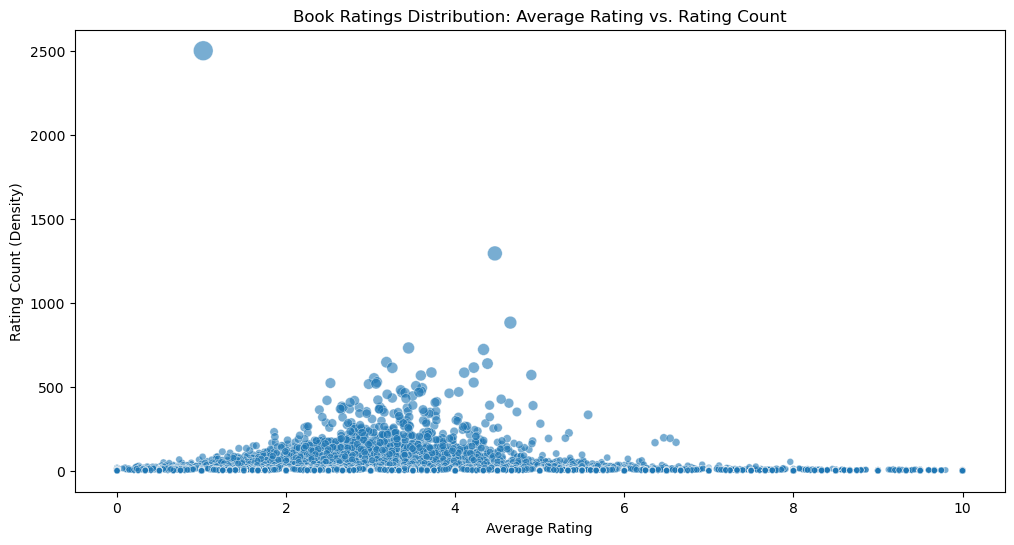

In [90]:
# Chart settings
plt.figure(figsize=(12, 6))

# Draw a scatter plot with point size proportional to the rating count
sns.scatterplot(
    data=book_ratings_summary,
    x='Average_Rating', 
    y='Rating_Count', 
    size='Rating_Count', 
    sizes=(20, 200), # Range of point sizes
    alpha=0.6,
    legend=False
)

# Set title and labels
plt.title('Book Ratings Distribution: Average Rating vs. Rating Count')
plt.xlabel('Average Rating')
plt.ylabel('Rating Count (Density)')
plt.show()


### Contribution between users and books

Maximum number of ratings given by a single user: 13602
Average number of ratings per user: 10.920851419507423


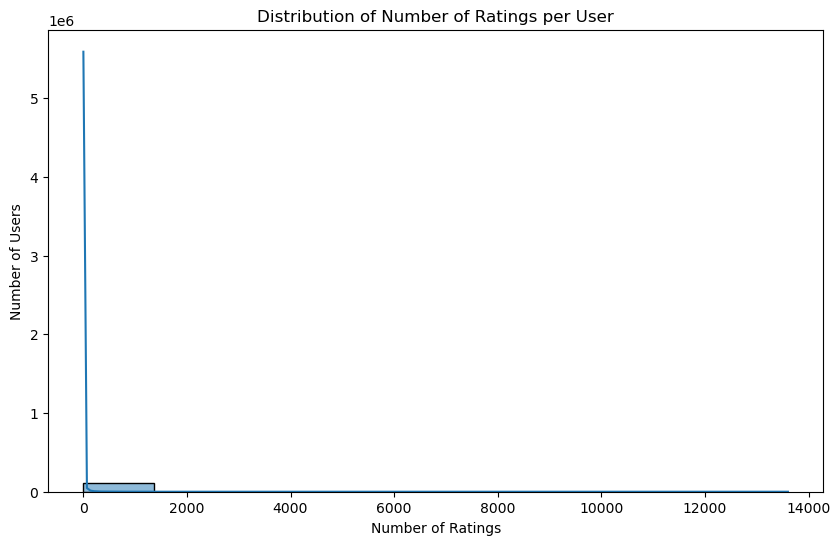

In [91]:
# Count the number of ratings for each user
user_counts = df['User-ID'].value_counts()

# Find the maximum number of ratings by a single user
max_ratings = user_counts.max()
print("Maximum number of ratings given by a single user:", max_ratings)

# Calculate the average number of ratings per user
average_ratings = user_counts.mean()
print("Average number of ratings per user:", average_ratings)

# Plot the distribution of the number of ratings per user
plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=10, kde=True)
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()


### Filterring unactive users

In [92]:
# unique users till now = 105283

# Filter users who have rated at least 10 times (active users)
active_users = user_counts[user_counts >= 10].index
df_active = df[df['User-ID'].isin(active_users)].copy()

print(type(active_users))
display(active_users)

display(df_active)
display(df_active.describe())

# Get the number of active users
num_active_users = active_users.shape[0]
print("Number of users with at least 10 ratings:", num_active_users)


<class 'pandas.core.indexes.numeric.Int64Index'>


Int64Index([ 11676, 198711, 153662,  98391,  35859, 212898, 278418,  76352,
            110973, 235105,
            ...
             61710, 240348, 124200, 246478, 205999, 124125, 205992, 257596,
             93968, 181997],
           dtype='int64', length=13097)

,User-ID,ISBN,Book-Rating
31,276762,034544003X,0
32,276762,0380000059,0
33,276762,0380711524,5
34,276762,0451167317,0
35,276762,0451454952,0
...,...,...,...
1149771,276704,0743211383,7
1149772,276704,080410526X,0
1149773,276704,0806917695,5
1149774,276704,0876044011,0


,User-ID,Book-Rating
count,965713.000000,965713.000000
mean,140602.846080,2.584712
std,80542.666004,3.776283
min,8.000000,0.000000
25%,70585.000000,0.000000
50%,141493.000000,0.000000
75%,211426.000000,7.000000
max,278851.000000,10.000000


Number of users with at least 10 ratings: 13097


### creating sparse matrix

In [93]:
# Map User-ID and ISBN to integer indices for sparse matrix
user_mapping = {user_id: idx for idx, user_id in enumerate(df_active['User-ID'].unique())}

print("my users: ", len(user_mapping))
# display(user_mapping)

book_mapping = {isbn: idx for idx, isbn in enumerate(df_active['ISBN'].unique())}

print("my books: ", len(book_mapping))
# display(book_mapping)

# Add indices to DataFrame
df_active['User_Index'] = df_active['User-ID'].map(user_mapping)
df_active['Book_Index'] = df_active['ISBN'].map(book_mapping)

# Create the sparse matrix (rows = users, columns = books, values = ratings)
sparse_matrix = csr_matrix((df_active['Book-Rating'], (df_active['User_Index'], df_active['Book_Index'])), 
                           shape=(len(user_mapping), len(book_mapping)))

print("Sparse matrix created with shape:", sparse_matrix.shape)

print(type(sparse_matrix))
sparse_matrix

my users:  13097
my books:  306779
Sparse matrix created with shape: (13097, 306779)
<class 'scipy.sparse._csr.csr_matrix'>


<13097x306779 sparse matrix of type '<class 'numpy.int64'>'
	with 965713 stored elements in Compressed Sparse Row format>

In [94]:
# display(user_mapping)

# display(book_mapping)

# A quick view of the data before converting to a sparse matrix
display(df_active[['User_Index', 'Book_Index', 'Book-Rating']].head(10))

# Display a small part of the matrix
print(sparse_matrix[:10, :10].toarray())

# print(sparse_matrix.shape)

,User_Index,Book_Index,Book-Rating
31,0,0,0
32,0,1,0
33,0,2,5
34,0,3,0
35,0,4,0
36,0,5,0
37,0,6,0
38,0,7,0
39,0,8,0
40,0,9,0


[[0 0 5 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


Applying KNN using Cosine

In [95]:
# Assuming sparse_matrix has been created from previous steps
# Creating the KNN model using Cosine Similarity
knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=5, n_jobs=-1)
knn_model.fit(sparse_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1)

In [96]:
# Function to find nearest neighbors with Mean-Centered Cosine Similarity
def find_nearest_neighbors_advanced(knn_model, user_vector, n_neighbors=5, existing_user=False):
    """
    Finds the nearest neighbors for a given user vector, with an option to exclude
    neighbors with similarity >= 0.9999 if the user already exists in the system.
    
    Parameters:
        knn_model (NearestNeighbors): Trained KNN model.
        user_vector (csr_matrix): Sparse matrix row representing the user.
        n_neighbors (int): Number of nearest neighbors to retrieve.
        existing_user (bool): Flag indicating if the user is already in the system.

    Returns:
        List of tuples containing neighbor index and similarity.
    """
    # Request more neighbors to account for potential filtering
    extra_neighbors = n_neighbors + 1  # Request additional neighbors to ensure we get at least `n_neighbors`
    distances, indices = knn_model.kneighbors(user_vector, n_neighbors=extra_neighbors)
    
    neighbors = []
    for i, (distance, index) in enumerate(zip(distances.flatten(), indices.flatten())):
        similarity = 1 - distance  # Convert cosine distance to similarity

        # Apply condition to exclude neighbors with similarity >= 0.9999 if existing_user is True
        if existing_user and similarity >= 0.9999:
            continue  # Skip this neighbor

        neighbors.append((index, similarity))

        # Stop when we have gathered the required number of neighbors
        if len(neighbors) == n_neighbors:
            break

    # Display selected neighbors
    for i, (index, similarity) in enumerate(neighbors, start=1):
        print(f"Neighbor {i}: User Index = {index}, Similarity = {similarity}")
    
    return neighbors


In [97]:
def find_nearest_neighbors(knn_model, user_vector, n_neighbors=5):
    """
    Finds the nearest neighbors for a given user vector.
    
    Parameters:
        knn_model (NearestNeighbors): Trained KNN model.
        user_vector (csr_matrix): Sparse matrix row representing the user.
        n_neighbors (int): Number of nearest neighbors to retrieve.

    Returns:
        List of tuples containing neighbor index and cosine distance.
    """
    # Find the nearest neighbors for the provided user vector
    distances, indices = knn_model.kneighbors(user_vector, n_neighbors=n_neighbors)

    # Display the results
    neighbors = []
    for i, (distance, index) in enumerate(zip(distances.flatten(), indices.flatten())):
        neighbors.append((index, distance))
        print(f"Neighbor {i+1}: User Index = {index}, Cosine Distance = {distance}")
    
    return neighbors

In [98]:
def recommend_books_optimized(sparse_matrix, user_vector, neighbors, top_n=5):
    """
    Optimized version to recommend books for a given user based on nearest neighbors' ratings.
    
    Parameters:
        sparse_matrix (csr_matrix): The main sparse matrix containing all user-book ratings.
        user_vector (csr_matrix): Sparse matrix row representing the user.
        neighbors (list of tuples): List of tuples, where each tuple contains (neighbor_index, similarity).
        top_n (int): Number of top recommended books to return.

    Returns:
        List of tuples containing book index and predicted rating.
    """
    # Identify books the user has not rated
    user_ratings = user_vector.toarray().flatten()
    unrated_books = np.where(user_ratings == 0)[0]

    # Extract neighbors' indices and similarities separately
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Calculate predicted ratings for unrated books in a vectorized way
    book_scores = {}
    for book_index in unrated_books:
        # Extract ratings of neighbors for this specific book
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()

        # Calculate weighted sum and similarity sum only where neighbor_rating > 0
        valid_ratings_mask = neighbor_ratings > 0
        weighted_sum = np.dot(similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
        similarity_sum = np.sum(similarities[valid_ratings_mask])

        # Avoid division by zero
        if similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
            book_scores[book_index] = predicted_rating

    # Sort books by predicted rating and return top recommendations
    recommended_books = sorted(book_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return recommended_books


In [99]:
from collections import defaultdict

# Function to recommend books based on nearest neighbors' ratings with frequency consideration
def recommend_books_with_frequency(sparse_matrix, user_vector, neighbors, top_n=5):
    """
    Recommend books based on both the predicted rating and frequency of occurrence among neighbors.
    
    Parameters:
        sparse_matrix (csr_matrix): The main sparse matrix containing all user-book ratings.
        user_vector (csr_matrix): Sparse matrix row representing the user.
        neighbors (list of tuples): List of tuples, where each tuple contains (neighbor_index, similarity).
        top_n (int): Number of top recommended books to return.

    Returns:
        List of tuples containing book index and predicted rating.
    """
    # Identify books the user has not rated
    user_ratings = user_vector.toarray().flatten()
    unrated_books = np.where(user_ratings == 0)[0]

    # Create a dictionary to hold the total weighted scores and frequency counts
    book_scores = defaultdict(float)
    book_frequencies = defaultdict(int)
    
    # Separate indices and similarities of neighbors
    neighbor_indices = np.array([int(n[0]) for n in neighbors])
    similarities = np.array([n[1] for n in neighbors])

    # Calculate scores and frequency counts
    for book_index in unrated_books:
        neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()
        
        # Only consider neighbors with non-zero ratings
        valid_ratings_mask = neighbor_ratings > 0
        if np.any(valid_ratings_mask):
            # Weighted sum of ratings by similarity
            weighted_sum = np.dot(similarities[valid_ratings_mask], neighbor_ratings[valid_ratings_mask])
            similarity_sum = np.sum(similarities[valid_ratings_mask])

            if similarity_sum > 0:
                predicted_rating = weighted_sum / similarity_sum
                book_scores[book_index] += predicted_rating
                book_frequencies[book_index] += np.sum(valid_ratings_mask)  # Count the number of neighbors who rated this book

    # Combine scores and frequencies to prioritize frequent, highly-rated books
    combined_scores = {book: (book_scores[book], book_frequencies[book]) for book in book_scores}

    # Sort by frequency first, then by predicted rating
    recommended_books = sorted(combined_scores.items(), key=lambda x: (x[1][1], x[1][0]), reverse=True)[:top_n]

    return recommended_books

In [100]:
def display_recommended_books(recommended_books, book_mapping):
    """
    Displays recommended books with their ISBN, title, and predicted rating.
    
    Parameters:
        recommended_books (list of tuples): List of (book_index, predicted_rating).
        book_mapping (dict): Dictionary mapping ISBNs to integer indices.
        df_active (DataFrame): DataFrame containing book details with columns 'ISBN' and 'Title'.
    """
    # Reverse book_mapping to map indices back to ISBNs
    index_to_isbn = {index: isbn for isbn, index in book_mapping.items()}
    
    print("Recommended Books:")
    for book_index, predicted_rating in recommended_books:
        # Convert index to ISBN
        isbn = index_to_isbn.get(book_index, "Unknown ISBN")

        print(f"ISBN: {isbn}, Predicted Rating: {predicted_rating:.4f}")

In [101]:
def display_recommended_books_frequency(recommended_books, book_mapping):
    # Map book indices to ISBN
    index_to_isbn = {index: isbn for isbn, index in book_mapping.items()}
    
    if not recommended_books:
        print("No recommended books available.")
        return
    
    print("Recommended Books:")
    for book_index, (predicted_rating, frequency) in recommended_books:
        # Retrieve ISBN for the book index or show "Unknown ISBN" if not found
        isbn = index_to_isbn.get(book_index, "Unknown ISBN")
        
        # Optionally limit predicted_rating to a certain range (e.g., 1 to 10)
        predicted_rating = max(1, min(10, predicted_rating))
        
        # Display the book with its ISBN, predicted rating, and frequency
        print(f"ISBN: {isbn}, Predicted Rating: {predicted_rating:.4f}, Frequency: {frequency}")

In [102]:
def save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors, file_path="neighbor_ratings.txt"):
    # Identify books the user has not rated using the user_vector
    user_ratings_original = user_vector.toarray().flatten()  # Convert to dense array and flatten
    unrated_books = np.where(user_ratings_original == 0)[0]

    # Extract neighbors' indices
    neighbor_indices = np.array([int(n[0]) for n in neighbors])

    with open(file_path, "w") as f:
        f.write("Unrated books by the target user and ratings from neighbors:\n\n")
        
        # Iterate over each unrated book
        for book_index in unrated_books:
            f.write(f"Book Index: {book_index}\n")

            # Get the ratings from neighbors for this specific book
            neighbor_ratings = sparse_matrix[neighbor_indices, book_index].toarray().flatten()
            
            # Write ratings given by each neighbor for this book
            for i, neighbor_index in enumerate(neighbor_indices):
                f.write(f"  Neighbor {i+1} (User Index: {neighbor_index}) - Rating: {neighbor_ratings[i]}\n")
            
            f.write("-" * 30 + "\n")  # Separator for each book


In [103]:
def save_nonzero_ratings_per_neighbor(sparse_matrix, neighbors, file_path="neighbor_nonzero_ratings_with_scores.txt"):
    """
    Saves the list of books with non-zero ratings and their scores for each neighbor to a text file.
    
    Parameters:
        sparse_matrix (csr_matrix): The main sparse matrix containing all user-book ratings.
        neighbors (list of tuples): List of tuples, where each tuple contains (neighbor_index, similarity).
        file_path (str): Path to save the output file.
    """
    with open(file_path, "w") as f:
        f.write("Books with non-zero ratings and their scores by each neighbor:\n\n")
        
        for i, (neighbor_index, similarity) in enumerate(neighbors, start=1):
            # Extract the ratings of the current neighbor (user)
            neighbor_ratings = sparse_matrix[neighbor_index].toarray().flatten()
            
            # Find indices of books with non-zero ratings and their corresponding scores
            nonzero_book_indices = np.where(neighbor_ratings > 0)[0]
            nonzero_book_ratings = neighbor_ratings[nonzero_book_indices]

            # Write neighbor information and ratings to the file
            f.write(f"Neighbor {i} (User Index: {neighbor_index}, Similarity: {similarity}):\n")
            f.write("Books with non-zero ratings and their scores:\n")
            
            for book_index, rating in zip(nonzero_book_indices, nonzero_book_ratings):
                f.write(f"  Book Index: {book_index}, Rating: {rating}\n")

            f.write("-" * 50 + "\n")

            # Optional: Print details in console for debugging
            print(f"Neighbor {i} (User Index: {neighbor_index}) has rated books and scores: {list(zip(nonzero_book_indices, nonzero_book_ratings))}")

    print(f"Results saved to {file_path}")


## Best Combination

In [104]:
# Find nearest neighbors for an existing user

user_index = 0  # for example, the first user
user_vector = sparse_matrix[user_index]

# print(type(user_vector))
print("Cosine similarity!")

# Find and print nearest neighbors for this user
neighbors = find_nearest_neighbors_advanced(knn_model, user_vector, n_neighbors=5, existing_user=True)

save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors)

recommended_books = recommend_books_with_frequency(sparse_matrix, user_vector, neighbors, top_n=5)

# print("Recommended book's index for user:", recommended_books)
print("neighbors: ", neighbors)

save_nonzero_ratings_per_neighbor(sparse_matrix, neighbors)

# Call the function to display recommended books
display_recommended_books_frequency(recommended_books, book_mapping)

Cosine similarity!
Neighbor 1: User Index = 8190, Similarity = 0.17191859455172476
Neighbor 2: User Index = 9689, Similarity = 0.14093960239411207
Neighbor 3: User Index = 618, Similarity = 0.12059155849275083
Neighbor 4: User Index = 6863, Similarity = 0.08132702314332241
Neighbor 5: User Index = 8231, Similarity = 0.07842764352626463
neighbors:  [(8190, 0.17191859455172476), (9689, 0.14093960239411207), (618, 0.12059155849275083), (6863, 0.08132702314332241), (8231, 0.07842764352626463)]
Neighbor 1 (User Index: 8190) has rated books and scores: [(2, 9), (3814, 9), (20496, 7), (22020, 7), (47189, 5), (72010, 8), (78365, 5), (87472, 7), (131581, 8), (210903, 5), (225778, 5), (225779, 8)]
Neighbor 2 (User Index: 9689) has rated books and scores: [(2, 5), (9754, 7), (11720, 6), (11958, 7), (26720, 6), (28698, 9)]
Neighbor 3 (User Index: 618) has rated books and scores: [(2, 5), (673, 5), (1209, 8), (1289, 8), (2767, 5), (10426, 8), (16927, 6), (39944, 7), (39945, 5)]
Neighbor 4 (User Ind

In [105]:
# Finding nearest neighbors for a random user

# finding the max and min of the rating
min_rating = df['Book-Rating'].min()
max_rating = df['Book-Rating'].max()

# showing the period of rating
print("Rating range:", min_rating, "to", max_rating)


# Create a random user vector
num_books = sparse_matrix.shape[1]
random_user_ratings = np.random.randint(min_rating, max_rating+1, size=num_books)
random_user_sparse = csr_matrix(random_user_ratings)

print(type(random_user_sparse))

# Find and print nearest neighbors for this user
neighbors = find_nearest_neighbors(knn_model, random_user_sparse, n_neighbors=5)

recommended_books = recommend_books_optimized(sparse_matrix, random_user_sparse, neighbors, top_n=5)

# print("Recommended books for user:", recommended_books)

# Call the function to display recommended books
display_recommended_books(recommended_books, book_mapping)

Rating range: 0 to 10
<class 'scipy.sparse._csr.csr_matrix'>
Neighbor 1: User Index = 575, Cosine Distance = 0.8647536594244895
Neighbor 2: User Index = 4771, Cosine Distance = 0.8859006033859528
Neighbor 3: User Index = 7308, Cosine Distance = 0.9313888308612894
Neighbor 4: User Index = 8981, Cosine Distance = 0.9335941926159786
Neighbor 5: User Index = 1147, Cosine Distance = 0.9450239876869884
Recommended Books:
ISBN: 0345450175, Predicted Rating: 10.0000
ISBN: 0671042858, Predicted Rating: 10.0000
ISBN: 080505622X, Predicted Rating: 10.0000
ISBN: 0425158616, Predicted Rating: 10.0000
ISBN: 0385510438, Predicted Rating: 10.0000


In [106]:
# Find nearest neighbors for an existing user

user_index = 0  # for example, the first user
user_vector = sparse_matrix[user_index]

print(type(user_vector))

# Find and print nearest neighbors for this user
neighbors = find_nearest_neighbors(knn_model, user_vector, n_neighbors=5)

save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors)

recommended_books = recommend_books_optimized(sparse_matrix, user_vector, neighbors, top_n=5)

# print("Recommended book's index for user:", recommended_books)

# Call the function to display recommended books
display_recommended_books(recommended_books, book_mapping)

<class 'scipy.sparse._csr.csr_matrix'>
Neighbor 1: User Index = 0, Cosine Distance = 0.0
Neighbor 2: User Index = 8190, Cosine Distance = 0.8280814054482752
Neighbor 3: User Index = 9689, Cosine Distance = 0.8590603976058879
Neighbor 4: User Index = 618, Cosine Distance = 0.8794084415072492
Neighbor 5: User Index = 6863, Cosine Distance = 0.9186729768566776


In [ ]:
# Find nearest neighbors for an existing user

user_index = 0  # for example, the first user
user_vector = sparse_matrix[user_index]

print(type(user_vector))

# Find and print nearest neighbors for this user
neighbors = find_nearest_neighbors_advanced(knn_model, user_vector, n_neighbors=5, existing_user=True)

save_neighbor_ratings_to_file(sparse_matrix, user_vector, neighbors)

recommended_books = recommend_books_optimized(sparse_matrix, user_vector, neighbors, top_n=5)

# print("Recommended book's index for user:", recommended_books)

# Call the function to display recommended books
display_recommended_books(recommended_books, book_mapping)

<class 'scipy.sparse._csr.csr_matrix'>
Neighbor 1: User Index = 8190, Similarity = 0.17191859455172476
Neighbor 2: User Index = 9689, Similarity = 0.14093960239411207
Neighbor 3: User Index = 618, Similarity = 0.12059155849275083
Neighbor 4: User Index = 6863, Similarity = 0.08132702314332241
Neighbor 5: User Index = 8231, Similarity = 0.07842764352626463
Recommended Books:
ISBN: 0679731148, Predicted Rating: 10.0000
ISBN: 1898307148, Predicted Rating: 10.0000
ISBN: 0804119716, Predicted Rating: 10.0000
ISBN: 0804119724, Predicted Rating: 10.0000
ISBN: 1575666065, Predicted Rating: 10.0000
